# IZ-DCE Demo

Import

In [38]:
from __future__ import annotations

import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pyiqa
import torch
from torch import Tensor

from iz_dce import iz_dce
from iz_dce.utils import get_coords
from mon import cv, Path, Size, to_image_array, transform as T
from mon.cv import write_image

Setup environment

In [39]:
current_dir = Path(os.getcwd())
root_dir = current_dir.parents[0]
data_dir = current_dir / "demo"
output_dir = current_dir / "demo"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}

# Debug
print(f"Device: {device}")

Device: cuda


Resolve I/O

In [40]:
# image_name = "993_UHD_LL"
# image_name = "1513_UHD_LL"
# image_name = "a0016-jmac_MG_0795"
image_name = "lol_v1_22"
# image_name = "lsrw_2038"
# image_name = "sice_1"

image_file = (data_dir / image_name / f"{image_name}").image_file
depth_file = (data_dir / image_name / f"{image_name}_depth").image_file
target_file = (data_dir / image_name / f"{image_name}_target").image_file

# Load data
image = cv2.imread(str(image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

depth = cv2.imread(str(depth_file), cv2.IMREAD_GRAYSCALE)
if depth.ndim == 2:
    depth = np.expand_dims(depth, axis=-1)

target = cv2.imread(str(target_file))
target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

# Debug
print(f"Image shape : {image.shape}")
print(f"Depth shape : {depth.shape}")
print(f"target shape: {target.shape}")
assert image.shape[0:2] == depth.shape[0:2], "'image' and 'depth' must have the same resolution."

Image shape : (400, 600, 3)
Depth shape : (400, 600, 1)
target shape: (400, 600, 3)


Pre-process

In [41]:
# Normalize and convert to torch.Tensor
transform = T.Compose([
    # T.Resize(512, 512),
    T.NormalizeWithMask(normalization="min_max"),
    T.ToTensorV2(transpose_mask=True),
], additional_targets={"target": "image"})
transformed = transform(image=image, mask=depth, target=target)

image_t = transformed["image"]
depth_t = transformed["mask"]
target_t = transformed["target"]

image_t = image_t.unsqueeze(0).to(device)
depth_t = depth_t.unsqueeze(0).to(device)
target_t = target_t.unsqueeze(0).to(device)

# Debug
print(f"Image shape : {image_t.shape}. Type: {image_t.dtype}. Device: {image_t.device}.")
print(f"Depth shape : {depth_t.shape}. Type: {depth_t.dtype}. Device: {depth_t.device}.")
print(f"target shape: {target_t.shape}. Type: {target_t.dtype}. Device: {target_t.device}.")

Image shape : torch.Size([1, 3, 400, 600]). Type: torch.float32. Device: cuda:0.
Depth shape : torch.Size([1, 1, 400, 600]). Type: torch.float32. Device: cuda:0.
target shape: torch.Size([1, 3, 400, 600]). Type: torch.float32. Device: cuda:0.


Process

In [42]:
def test_baseline(
    image_: Tensor,
    depth_: Tensor,
    epochs: int = 100,
    E: float = 0.3,
    save_debug: bool = True,
    verbose: bool = False,
):
    global results, device

    colie = cv.colie(device=device, verbose=verbose)

    results["colie"] = colie(image=image_, epochs=epochs, E=E, save_debug=save_debug)

In [43]:
def test_arch(
    image_: Tensor,
    depth_: Tensor,
    save_debug: bool = True,
    verbose: bool = False,
):
    global results, device

    # Define model
    model = iz_dce().to(device)
    weights = Path("/home/longpham/10_workspace/11_code/mon/projects/dev/run/train/iz_dce/iz_dce_sice_me/last.pt")
    if weights.is_weights_file(exists=True):
        model.load_state_dict(torch.load(str(weights)))
    model.eval()

    outputs = model.forward(image_, depth_)
    enhanced = outputs["enhanced"]

    results["iz_dce"] = {"enhanced": enhanced}

In [44]:
# test_baseline(image_t, depth_t)

In [45]:
test_arch(image_t, depth_t)

[20:56:26] Initialized 'iz_dce' from scratch.                                                          ]8;id=427023;file:///home/longpham/10_workspace/11_code/mon/projects/dev/src/iz_dce/model.py\model.py]8;;\:]8;id=279501;file:///home/longpham/10_workspace/11_code/mon/projects/dev/src/iz_dce/model.py#105\105]8;;\

Measure metrics

In [46]:
def measure_metrics(key: str = "enhanced"):
    global target_t, results, device

    # Create metrics with default settings
    psnr_metric = pyiqa.create_metric("psnr", device=device)
    ssim_metric = pyiqa.create_metric("ssim", device=device)
    lpips_metric = pyiqa.create_metric("lpips", device=device)
    niqe_metric = pyiqa.create_metric("niqe", device=device)
    brisque_metric = pyiqa.create_metric("brisque", device=device)
    musiq_metric = pyiqa.create_metric("musiq", device=device)

    # Concatenate results for visualization
    titles = ["image"]
    images = [image]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1[key])

    # Measure metrics
    target_ = target_t.to(device)
    for i in range(1, len(images)):
        if isinstance(images[i], Tensor):
            img_ = images[i].to(device)
        else:
            img_ = images[i]

        psnr_value = psnr_metric(img_, target_).item()
        ssim_value = ssim_metric(img_, target_).item()
        lpips_value = lpips_metric(img_, target_).item()
        niqe_value = niqe_metric(img_).item()
        brisque_value = brisque_metric(img_).item()
        musiq_value = musiq_metric(img_).item()

        print(
            f"{titles[i]:15s} "
            f"| PSNR: {psnr_value:6.2f} "
            f"| SSIM: {ssim_value:6.4f} "
            f"| LPIPS: {lpips_value:6.4f} "
            f"| NIQE: {niqe_value:6.4f} "
            f"| BRISQUE: {brisque_value:6.4f} "
            f"| MUSIQ: {musiq_value:6.4f}"
        )

In [47]:
measure_metrics("enhanced")

Loading pretrained model LPIPS from /home/longpham/.cache/torch/hub/checkpoints/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model MUSIQ from /home/longpham/.cache/torch/hub/checkpoints/musiq_koniq_ckpt-e95806b9.pth
iz_dce          | PSNR:  23.33 | SSIM: 0.7663 | LPIPS: 0.2774 | NIQE: 2.8552 | BRISQUE: 17.3961 | MUSIQ: 52.9269


Post-process

In [48]:
def postprocess():
    global image, results

    size0 = Size.from_value(image)

    # Convert outputs to numpy arrays
    for k1, v1 in results.items():
        for k2, v2 in v1.items():
            v2 = to_image_array(v2)

            size1 = Size.from_value(v2)
            if size0 != size1:
                v2 = cv2.resize(v2, size0.wh)

            results[k1][k2] = v2

In [49]:
postprocess()

Visualize

In [50]:
# Setup matplotlib
plt.rcParams["figure.autolayout"] = True

In [51]:
def compare_results(key: str = "enhanced"):
    global results

    # Concatenate results for visualization
    titles = ["image", "depth", "target"]
    images = [image, depth, target]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1[key])

    # Create a grid of images
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis("off")

    # Adjust the layout and show the plot
    plt.tight_layout()  # Adjust layout to prevent title overlap
    plt.show()

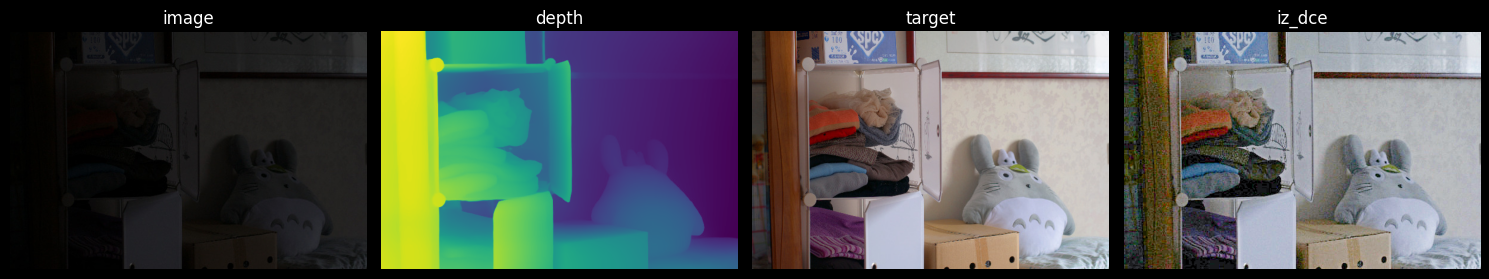

In [52]:
compare_results(key="enhanced")

Save

In [53]:
def save():
    global results

    for k1, v1 in results.items():
        for k2, v2 in v1.items():
            save_file = output_dir / f"{image_name}_debug" / f"{image_name}_{k1}_{k2}.jpg"
            write_image(v2, save_file)

In [54]:
save()